In [1]:
import os
import operator
from typing import Annotated, Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()

/home/rikesh/Rikesh/RAG/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [2]:
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [5]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_tool_use",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

print("Vector store ready")

Vector store ready


In [6]:
llm = ChatOpenAI(model="gpt-5-mini")        # route_question and generate

agent_llm = ChatOpenAI(model="gpt-5-mini")  # agent node; tools bound later

In [7]:
class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    context: Annotated[str, operator.add]
    generation: str
    needs_retrieval: bool

In [8]:
class RouteDecision(BaseModel):

    needs_retrieval: bool

In [9]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k: int = 3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages."""
    
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(query)
    
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)
    
    return context, docs

In [10]:
@tool(response_format="content_and_artifact")
def web_search(query: str, max_results: int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned."""
    
    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)
    return content, docs

In [11]:
tools = [vector_store_search, web_search]

agent_llm_with_tools = agent_llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [12]:
# route_question node — classifies whether the query needs retrieval
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [13]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)

# agent node — decides which tool(s) to call based on the query
def agent(state: AgenticRAGState) -> dict:

    messages = state["messages"]
    if not messages:
        messages = [SystemMessage(content=AGENT_SYSTEM_PROMPT),
                    HumanMessage(content=state["query"])]

    response = agent_llm_with_tools.invoke(messages)

    return {"messages": [response]}

In [14]:
# collect_tool_output node — drains ToolMessages into state fields
def collect_tool_output(state: AgenticRAGState) -> dict:

    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    all_docs, context_parts = [], []

    for msg in tool_messages:
        context_parts.append(msg.content)
        all_docs.extend(msg.artifact)

    return {
        "context": "\n\n".join(context_parts),
        "retrieved_docs": all_docs,
    }

In [15]:
# generate node — produces the final answer with or without retrieved context
def generate(state: AgenticRAGState) -> dict:

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})

    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [16]:
def route_after_classification(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "agent" if state["needs_retrieval"] else "generate"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

In [17]:
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("route_question", route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges("route_question", route_after_classification)
graph_builder.add_conditional_edges("agent", route_after_agent)
graph_builder.add_edge("tools", "agent")
graph_builder.add_edge("collect_tool_output", "generate")
graph_builder.add_edge("generate", END)

In [18]:
graph = graph_builder.compile()

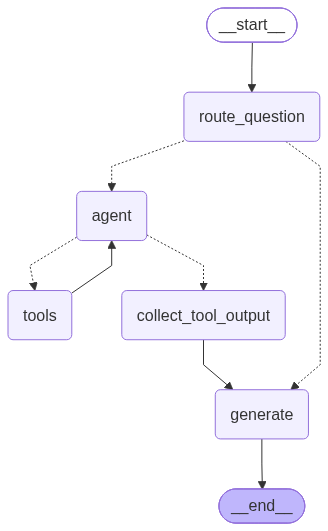

In [19]:
graph

In [20]:
# Case 1: vector store only — domain-specific question about the PDF
query_vs = "According to the report, how will the adoption of electric vehicles impact oil demand?"

result_vs = graph.invoke({"query": query_vs, "messages": [], "retrieved_docs": [], "context": ""})

In [21]:
print("=== CASE 1: Vector Store Only ===")
print(f"needs_retrieval : {result_vs['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_vs.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_vs.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_vs['generation']}")

=== CASE 1: Vector Store Only ===
needs_retrieval : True
retrieved_docs  : 6 docs
context preview : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
Briefly, the report’s findings are:

- EV adoption will reduce oil demand, mainly by displacing gasoline used in passenger cars.
- The displacement will be gradual because the global ICE vehicle stock (~1.4 billion) and long vehicle lifetimes (15–20+ years) mean full fleet turnover takes decades; the dampening effect is most pronounced after ~2035 and will first accrue to advanced economies.
- In the near term, EVs can flatten or reverse oil demand growth; this marginal effect (keeping spare capacity above the ~2–3 million b/d buffer) may matter more for price shock insurance than aggregate liters displaced.
- Heavy transport diesel demand is harder to electrify, so diesel is less affected than gasoline.
- A countervailing supply-side effect: lower oil 

In [22]:
print(result_vs["context"])



## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 8
4. EV Adoption Trajectories and Oil Demand Displacement
 Projecting oil demand displacement from EV adoption requires integrating three distinct
analytical layers: the annual sales trajectory for new EVs, the retirement rate of the existing
ICE fleet, and the average annual mileage and fuel economy of the vehicles being displaced.
The total stock of passenger vehicles globally stands at approximately 1.4 billion, the vast
majority of which are ICE vehicles. With global new vehicle sales of roughly 90 million units
per year and average vehicle lifetimes of 15 to 20 years in developed markets — and often
longer in developing markets — complete fleet electrification cannot occur in less than two to

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 7
consumption, the effect on price dynamics can

In [23]:
# Case 2: web search only — current information not in the PDF
query_web = "What is the current temperature in New Delhi?"

result_web = graph.invoke({"query": query_web, "messages": [], "retrieved_docs": [], "context": ""})

In [24]:
print("=== CASE 2: Web Search Only ===")
print(f"needs_retrieval : {result_web['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_web.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_web.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_web['generation']}")

=== CASE 2: Web Search Only ===
needs_retrieval : True
retrieved_docs  : 10 docs
context preview : 

## Web Search Results

Video 1:15

  Getty Images Video What did Jalen Brunson’s mom text him before the Knicks Finals...

Generation:
The current temperature in New Delhi is 29.0°C (84.2°F) — last updated 2026-08-11 23:30 local time.


In [25]:
# Case 3: both tools — requires document context AND current web data
query_both = "Compare what the EV report projects for 2030 oil demand and also tell me about the weather in mumbai"

result_both = graph.invoke({"query": query_both, "messages": [], "retrieved_docs": [], "context": ""})

In [26]:
print("=== CASE 3: Both Tools ===")
print(f"needs_retrieval : {result_both['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_both.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_both.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_both['generation']}")

=== CASE 3: Both Tools ===
needs_retrieval : True
retrieved_docs  : 8 docs
context preview : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
Short answer — two parts.

EV report (what it says about ~2030)
- The provided excerpts do not give a specific numeric projection for 2030 oil demand.  
- The report’s clear messages relevant to 2030 are: EV adoption is a meaningful structural mitigant but its price‑shock dampening is neither immediate nor sufficient on its own; the strongest effects are expected after ~2035 and will appear first in advanced economies.  
- Near term (around 2030) the report expects mostly marginal impacts: passenger EVs can flatten or modestly reverse demand growth for gasoline (helping keep global spare capacity above the ~2–3 million barrels/day insurance threshold), but aggregate fleet displacement will be limited because the global vehicle stock (~1.4 billion) plus annual 

In [27]:
print(result_both["context"])



## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 8
4. EV Adoption Trajectories and Oil Demand Displacement
 Projecting oil demand displacement from EV adoption requires integrating three distinct
analytical layers: the annual sales trajectory for new EVs, the retirement rate of the existing
ICE fleet, and the average annual mileage and fuel economy of the vehicles being displaced.
The total stock of passenger vehicles globally stands at approximately 1.4 billion, the vast
majority of which are ICE vehicles. With global new vehicle sales of roughly 90 million units
per year and average vehicle lifetimes of 15 to 20 years in developed markets — and often
longer in developing markets — complete fleet electrification cannot occur in less than two to

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 3
Executive Summary
 The global transition towa

In [28]:
# Case 4: no retrieval — answerable from general knowledge
query_none = "Explain the difference between kinetic energy and potential energy."

result_none = graph.invoke({"query": query_none, "messages": [], "retrieved_docs": [], "context": ""})

In [29]:
print("=== CASE 4: No Retrieval ===")
print(f"needs_retrieval : {result_none['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_none.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_none.get('context', '') or '(none)'}")
print(f"\nGeneration:\n{result_none['generation']}")

=== CASE 4: No Retrieval ===
needs_retrieval : False
retrieved_docs  : 0 docs
context preview : (none)

Generation:
Kinetic energy and potential energy are two forms of mechanical energy, but they come from different physical situations:

- Kinetic energy (KE) is the energy an object has because of its motion. For a point mass in classical mechanics KE = 1/2 m v^2 (m = mass, v = speed). Rotational kinetic energy is 1/2 I ω^2 (I = moment of inertia, ω = angular speed). KE is always non‑negative and depends on the observer’s reference frame (velocity is relative).

- Potential energy (PE) is energy stored in an object or system due to its position or configuration in a force field. Examples: gravitational PE near Earth U = m g h (h measured from a chosen zero), elastic PE of a spring U = 1/2 k x^2, electric potential energy between charges U = k q1 q2 / r. PE is defined for conservative forces and depends on the choice of reference (zero) level; it can be negative relative to that zero.


In [30]:
result_both["messages"][0].tool_calls

[{'name': 'vector_store_search',
  'args': {'query': 'Will EVs Dampen the Oil Price Shock? 2030 oil demand projection EV adoption displacement 2030 oil consumption',
   'k': 5},
  'id': 'call_isoKHNqr0CbkUJc179stmrxW',
  'type': 'tool_call'},
 {'name': 'web_search',
  'args': {'query': 'Mumbai weather now current temperature Mumbai forecast',
   'max_results': 3},
  'id': 'call_XiRzQpii9QyndN41dt9DLGNM',
  'type': 'tool_call'}]